# Exercise 1.1 — Reducing Dose

## 1. imports and setup

In [ ]:
import os
import sys

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.transform import radon, iradon
from skimage.metrics import (
    mean_squared_error,
    peak_signal_noise_ratio,
    structural_similarity,
)

from ct_reconstruction.phantom import load_ct_image

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 9

SAVE_DIR = "report_figures/exercise_1_1"
os.makedirs(SAVE_DIR, exist_ok=True)

## 2. Load image and mask it to the reconstruction circle

Phantom: CT chest image, shape=(512, 512), range=[0.000, 1.000]


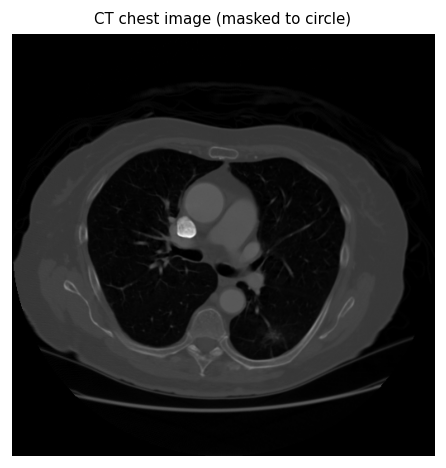

In [2]:
def circular_mask(shape):
    """
    Create a boolean mask for the inscribed reconstruction circle.
    """
    h, w = shape
    cy, cx = h / 2.0, w / 2.0
    yy, xx = np.ogrid[:h, :w]
    r = min(h, w) / 2.0
    return (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2


def apply_circular_mask(image):
    """
    Zero out pixels outside the inscribed reconstruction circle.
    """
    mask = circular_mask(image.shape)
    out = image.copy().astype(np.float64)
    out[~mask] = 0.0
    return out, mask


ct_path = "../CT_exercise_1.png"

if os.path.exists(ct_path):
    phantom = load_ct_image(ct_path)
    phantom_label = "CT chest image"
else:
    raise FileNotFoundError(
        "CT image not found and no fallback phantom loader is enabled."
    )

phantom = phantom.astype(np.float64)
phantom, recon_mask = apply_circular_mask(phantom)

print(
    f"Phantom: {phantom_label}, shape={phantom.shape}, "
    f"range=[{phantom.min():.3f}, {phantom.max():.3f}]"
)

plt.figure(figsize=(4, 4))
plt.imshow(phantom, cmap="gray")
plt.title(f"{phantom_label} (masked to circle)")
plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Clean sinogram generation

Before adding noise a clean parallel-beam sinogram is generated from masked image using random transform 
Projection angles are sampled uniformly 

theta shape   : (360,) range: 0.0° – 179.5°
sinogram shape: (512, 360) (detectors × angles)


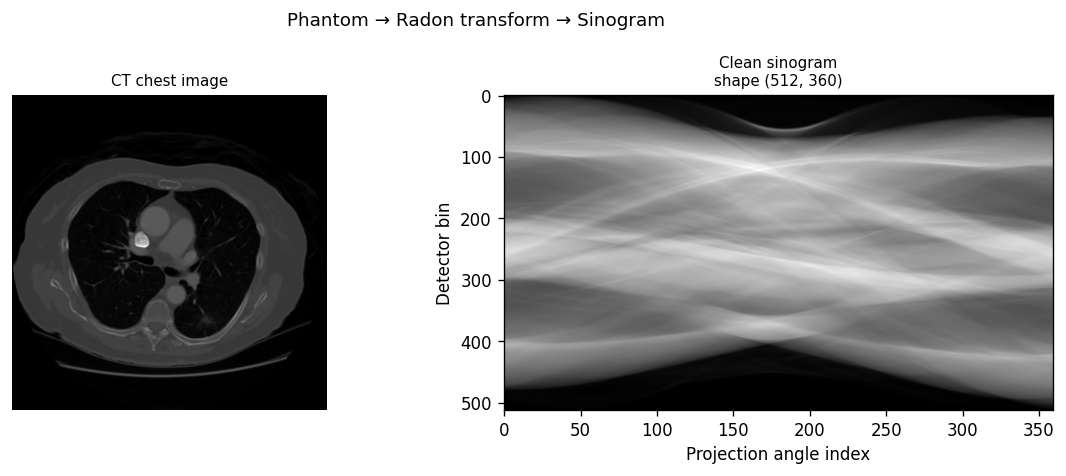

In [3]:
def make_theta(n_angles):
    """
    Generate projection angles in degrees over [0, 180).
    """
    return np.linspace(0.0, 180.0, n_angles, endpoint=False)


def compute_clean_sinogram(image, n_angles):
    """
    Compute the clean parallel-beam sinogram given a number of views.
    """
    theta = make_theta(n_angles)
    sino = radon(image, theta=theta, circle=True)
    return theta, sino


theta = make_theta(360)
sinogram = radon(phantom, theta=theta, circle=True)

print(f"theta shape   : {theta.shape} range: {theta[0]:.1f}\u00b0 \u2013 {theta[-1]:.1f}\u00b0")
print(f"sinogram shape: {sinogram.shape} (detectors \u00d7 angles)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(phantom, cmap="gray")
axes[0].set_title(phantom_label)
axes[0].axis("off")

axes[1].imshow(sinogram, cmap="gray", aspect="auto")
axes[1].set_title(f"Clean sinogram\nshape {sinogram.shape}")
axes[1].set_xlabel("Projection angle index")
axes[1].set_ylabel("Detector bin")

plt.suptitle("Phantom \u2192 Radon transform \u2192 Sinogram", fontsize=11)
plt.tight_layout()
plt.show()

## 4. Combined noise model (Gaussian + Poisson)

Gaussian electronic detector noise and Poisson photon noise are applied together
in the transmission domain, following the physical acquisition order (Practical 2, Q3a–Q3b):

1. $I = I_0 \exp(-p)$ — Beer-Lambert (sinogram normalised first per practical hint)
2. $I_\text{Gauss} = I + \mathcal{N}(0, \sigma^2)$ — Gaussian detector noise added first
3. $I_\text{Poisson} \sim \text{Poisson}(I_\text{Gauss})$ — photon counting noise applied to the perturbed counts
4. $p_\text{noisy} = -\log(I_\text{Poisson} / I_0)$ — back to attenuation scale

In [4]:
def simulate_noisy_sinogram(sinogram, I0, sigma=0.05, rng=None):
    """
    Simulate a noisy sinogram following the physical CT acquisition pipeline.

    Applies Gaussian detector noise first, then Poisson photon noise,
    in the transmission domain. 

    Pipeline
    --------
    1. p_norm = sinogram / p_max            -- normalises raw 
    2. I = I0 * exp(-p_norm)               -- Beer-Lambert transmission counts
    3. I_gauss = I + N(0, sigma^2)         -- additive Gaussian detector noise
    4. I_poisson ~ Poisson(clip(I_gauss))  -- photon counting noise on perturbed counts
    5. clip(I_poisson, 1, None)            -- numerical stability (prevent log(0))
    6. p_noisy = -log(I_poisson / I0) * p_max -- back to ori
    """
    if rng is None:
        rng = np.random.default_rng()

    p_max = sinogram.max()
    if p_max == 0:
        return sinogram.copy()

    p_norm   = sinogram / p_max                            
    I        = I0 * np.exp(-p_norm)                         
    I_gauss  = I + rng.normal(0.0, sigma, size=sinogram.shape)         
    I_gauss  = np.clip(I_gauss, 1e-8, None)               
    I_noisy  = rng.poisson(I_gauss).astype(np.float64)    
    I_noisy  = np.clip(I_noisy, 1, None)                

    return -np.log(I_noisy / I0) * p_max                    

## 5. Build the experiment grid

3 angular resolutions × 3 dose levels = 9 conditions.
Each sinogram has both Poisson and Gaussian noise applied in the transmission domain.

In [5]:
rng = np.random.default_rng(42)

angle_list = [360, 90, 20]
I0_list    = [1e5, 1e3, 1e2]
sigma      = 0.05

noisy_results = {}

for n_angles in angle_list:
    noisy_results[n_angles] = {}
    theta, p_clean = compute_clean_sinogram(phantom, n_angles)

    for I0 in I0_list:
        p_noisy = simulate_noisy_sinogram(p_clean, I0=I0, sigma=sigma, rng=rng)

        noisy_results[n_angles][I0] = {
            "theta":   theta,
            "p_clean": p_clean,
            "p_noisy": p_noisy,
            "I0":      I0,
        }

## 6. Visualise noisy sinograms (Gaussian + Poisson)

In [ ]:
fig, axes = plt.subplots(len(I0_list), len(angle_list), figsize=(15, 10))

for i, I0 in enumerate(I0_list):
    for j, n_angles in enumerate(angle_list):
        ax = axes[i, j]
        p_noisy = noisy_results[n_angles][I0]["p_noisy"]

        im = ax.imshow(p_noisy, cmap="gray", aspect="auto")
        ax.set_title(f"Gaussian + Poisson noise\nI0={I0:.0e}, angles={n_angles}")
        ax.set_xlabel("Projection angle index")
        ax.set_ylabel("Detector bin")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"Noisy sinograms (sigma={sigma})", fontsize=12)
plt.tight_layout()
fig.savefig(f"{SAVE_DIR}/figure3_noisy_sinograms_clean.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Reconstruction functions

### 7a. FBP

In [7]:
def reconstruct_fbp_ramp(sinogram, theta, output_size):
    """
    Reconstruct an image using filtered backprojection (ramp filter).
    """
    return iradon(
        sinogram,
        theta=theta,
        filter_name="ramp",
        circle=True,
        output_size=output_size,
    )

### 7b. Unfiltered backprojection helper

### 7c. Approximate Landweber-style iterative reconstruction


In [8]:
def reconstruct_gradient_descent(
    sinogram,
    theta,
    output_size,
    phantom=None,
    mask=None,
    gamma=0.001,
    n_iter=200,
    verbose=False,
):
    """
    Gradient descent reconstruction.

    Update rule:  x^{k+1} = x^k − γ * A^T(Ax^k − b)
    where A = radon(), A^T = iradon(..., filter_name=None).
    Step size γ ≈ 0.001 as suggested in the practical hint.

    Residual MSE and image MSE are logged at x^k (before the update).
    """
    x = np.zeros((output_size, output_size), dtype=np.float64)
    residual_losses  = []
    image_mse_losses = []

    for it in range(n_iter):
        residual = radon(x, theta=theta, circle=True) - sinogram

        # Log loss at current iterate x^k before stepping
        residual_losses.append(float(np.mean(residual ** 2)))

        if phantom is not None:
            ref = phantom[mask] if mask is not None else phantom.ravel()
            est = x[mask]       if mask is not None else x.ravel()
            image_mse_losses.append(float(np.mean((ref - est) ** 2)))

        # A^T (Ax^k - b): unfiltered backprojection of the residual
        grad = iradon(residual, theta=theta, filter_name=None,
                      circle=True, output_size=output_size)
        x = x - gamma * grad

        if verbose and (it % 25 == 0 or it == n_iter - 1):
            msg = f"iter={it:03d}, residual={residual_losses[-1]:.6e}"
            if phantom is not None:
                msg += f", img_mse={image_mse_losses[-1]:.6e}"
            print(msg)

    return x, residual_losses, image_mse_losses

## 8. Metrics computed inside the valid reconstruction circle

These are **masked metrics**: PSNR and SSIM are evaluated only inside the circular
reconstruction support, so they should not be compared directly with whole-image values.

In [9]:
def compute_metrics(reference, reconstruction, mask=None):
    """
    Compute MSE, PSNR, and SSIM.

    If mask is provided, metrics are computed only inside the mask.
    """
    ref = np.asarray(reference, dtype=np.float64)
    rec = np.asarray(reconstruction, dtype=np.float64)

    if mask is not None:
        ref_eval = ref[mask]
        rec_eval = rec[mask]
        mse = np.mean((ref_eval - rec_eval) ** 2)

        data_range = ref_eval.max() - ref_eval.min()
        if data_range == 0:
            data_range = 1.0

        psnr = 10.0 * np.log10((data_range ** 2) / mse) if mse > 0 else np.inf

        # SSIM requires 2D arrays, so use full image with outside-mask zeroed
        ref_ssim = np.zeros_like(ref)
        rec_ssim = np.zeros_like(rec)
        ref_ssim[mask] = ref[mask]
        rec_ssim[mask] = rec[mask]

        ssim = structural_similarity(ref_ssim, rec_ssim, data_range=data_range)
    else:
        data_range = ref.max() - ref.min()
        if data_range == 0:
            data_range = 1.0

        mse = mean_squared_error(ref, rec)
        psnr = peak_signal_noise_ratio(ref, rec, data_range=data_range)
        ssim = structural_similarity(ref, rec, data_range=data_range)

    return {"MSE": mse, "PSNR": psnr, "SSIM": ssim}

## 9. Reconstruct all experiments (FBP + GD)

In [10]:
output_size = phantom.shape[0]
recon_results = {}

for n_angles in angle_list:
    recon_results[n_angles] = {}

    for I0 in I0_list:
        case    = noisy_results[n_angles][I0]
        theta   = case["theta"]
        p_noisy = case["p_noisy"]

        fbp_noisy = reconstruct_fbp_ramp(p_noisy, theta, output_size)

        gd_noisy, gd_noisy_res, gd_noisy_img = reconstruct_gradient_descent(
            p_noisy, theta, output_size, phantom=phantom, mask=recon_mask,
            gamma=0.001, n_iter=200,
        )

        recon_results[n_angles][I0] = {
            "fbp_noisy":                 fbp_noisy,
            "gd_noisy":                  gd_noisy,
            "gd_noisy_residual_losses":  gd_noisy_res,
            "gd_noisy_image_mse_losses": gd_noisy_img,
            "fbp_metrics_noisy": compute_metrics(phantom, fbp_noisy, mask=recon_mask),
            "gd_metrics_noisy":  compute_metrics(phantom, gd_noisy,  mask=recon_mask),
        }

print("All reconstructions complete.")

All reconstructions complete.


## 11. Plot GD convergence in projection and image domains

These curves refer to the approximate Landweber-style solver on the combined-noise sinograms. Both relative projection residual and image-domain MSE are shown so that projection-space improvement is not over-interpreted as image-quality improvement.

In [ ]:
ordered_I0     = sorted(I0_list, reverse=True)
ordered_angles = sorted(angle_list, reverse=True)

fig, axes = plt.subplots(
    len(ordered_I0), len(ordered_angles),
    figsize=(15, 10), sharex=True,
)

for i, I0 in enumerate(ordered_I0):
    for j, n_angles in enumerate(ordered_angles):
        ax   = axes[i, j]
        case = recon_results[n_angles][I0]
        sino = noisy_results[n_angles][I0]["p_noisy"]

        rel_res = (np.sqrt(np.asarray(case["gd_noisy_residual_losses"]) * sino.size)
                   / (np.linalg.norm(sino) + 1e-12))
        img_mse = np.asarray(case["gd_noisy_image_mse_losses"])

        ax.plot(rel_res, color="tab:blue",   linewidth=2, label="Relative residual")
        ax.plot(img_mse, color="tab:orange", linewidth=2, label="Image MSE")
        ax.set_title(f"I0={I0:.0e}, angles={n_angles}")
        ax.set_xlabel("Iteration")
        if j == 0:
            ax.set_ylabel("Loss")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.01))
fig.suptitle("GD convergence — Gaussian + Poisson noisy sinograms", fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(f"{SAVE_DIR}/gd_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

Because the GD is an iterative method it produces a convergance curve, FBP is a one-shot method and produces one point. 
Analysis of the above plots:
- while decreasing the number of andgles and the amount of photon dosage the residual curve looks similar - always in a decreasing trend
- however the MSE gets worse - especially with fewer projection angles, the reconstruction error becomes more ill-posed leading to earlier and stronger overfitting in grandient descent 

## 12. Reconstruction visual comparison

All figures below use the same grayscale and absolute-error limits across Gaussian and Poisson experiments. This keeps the comparison visually fair across reconstruction methods, view counts, and dose levels.

### 12. Reconstruction visual comparison by dose level

In [ ]:
gray_cm = plt.cm.gray.copy()
gray_cm.set_bad("white")
err_cm = plt.cm.inferno.copy()
err_cm.set_bad("white")

def masked(img):
    return np.ma.masked_where(~recon_mask, img)

# Shared intensity scale across all reconstructions
all_imgs = [phantom]
for n_angles in angle_list:
    for I0 in I0_list:
        case = recon_results[n_angles][I0]
        all_imgs.extend([case["fbp_noisy"], case["gd_noisy"]])
img_vmin, img_vmax = np.percentile(
    np.concatenate([img[recon_mask].ravel() for img in all_imgs]), [1, 99])

ordered_angles = sorted(angle_list, reverse=True)
col_titles = ["FBP", "FBP error", "GD", "GD error"]
I0_label_map = {1e5: "1e5", 1e3: "1e3", 1e2: "1e2"}

for I0 in sorted(I0_list, reverse=True):
    # Per-dose error scale so low-dose errors are not washed out
    all_errs_I0 = [np.abs(phantom - recon_results[n][I0][k])
                   for n in ordered_angles for k in ("fbp_noisy", "gd_noisy")]
    err_vmax = float(np.percentile(
        np.concatenate([v[recon_mask].ravel() for v in all_errs_I0]), 99.5))

    fig, axes = plt.subplots(len(ordered_angles), 4, figsize=(11, 8), constrained_layout=True)
    if len(ordered_angles) == 1:
        axes = axes[None, :]

    err_im = None
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=10, fontweight="semibold")

    for i, n_angles in enumerate(ordered_angles):
        case  = recon_results[n_angles][I0]
        fbp   = case["fbp_noisy"]
        gd    = case["gd_noisy"]
        fbp_m = case["fbp_metrics_noisy"]
        gd_m  = case["gd_metrics_noisy"]

        axes[i, 0].imshow(masked(fbp), cmap=gray_cm, vmin=img_vmin, vmax=img_vmax)
        axes[i, 1].imshow(masked(np.abs(phantom - fbp)), cmap=err_cm, vmin=0, vmax=err_vmax)
        axes[i, 2].imshow(masked(gd), cmap=gray_cm, vmin=img_vmin, vmax=img_vmax)
        err_im = axes[i, 3].imshow(masked(np.abs(phantom - gd)), cmap=err_cm, vmin=0, vmax=err_vmax)

        axes[i, 0].text(0.98, 0.02, f"PSNR {fbp_m['PSNR']:.1f} dB",
                        transform=axes[i, 0].transAxes, ha="right", va="bottom",
                        fontsize=7.5, color="white",
                        bbox=dict(facecolor="black", alpha=0.45, pad=1.5, linewidth=0))
        axes[i, 2].text(0.98, 0.02, f"PSNR {gd_m['PSNR']:.1f} dB",
                        transform=axes[i, 2].transAxes, ha="right", va="bottom",
                        fontsize=7.5, color="white",
                        bbox=dict(facecolor="black", alpha=0.45, pad=1.5, linewidth=0))

        for j in range(4):
            ax = axes[i, j]
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_facecolor("white")
            for sp in ax.spines.values():
                sp.set_visible(False)

        axes[i, 0].set_ylabel(f"{n_angles} views", fontsize=10, fontweight="semibold")

    fig.colorbar(err_im, ax=axes, shrink=0.82, pad=0.02, label="Absolute error")
    fig.suptitle(
        f"Gaussian + Poisson noise ($I_0$ = {I0:.0e}, $\\sigma$ = {sigma})",
        fontsize=12, fontweight="semibold",
    )
    fig.savefig(f"{SAVE_DIR}/recon_I0_{I0_label_map[I0]}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 13. Quantitative metrics table — Combined-noise experiments

In [13]:
rows = []

for n_angles in angle_list:
    for I0 in I0_list:
        fbp_m = recon_results[n_angles][I0]["fbp_metrics_noisy"]
        gd_m  = recon_results[n_angles][I0]["gd_metrics_noisy"]

        for method, m in [("FBP", fbp_m), ("GD", gd_m)]:
            rows.append({
                "I0":     I0,
                "angles": n_angles,
                "method": method,
                "MSE":    m["MSE"],
                "PSNR":   m["PSNR"],
                "SSIM":   m["SSIM"],
            })

metrics_df = pd.DataFrame(rows).sort_values(
    ["I0", "angles", "method"], ascending=[False, False, True]
).reset_index(drop=True)

metrics_df

,I0,angles,method,MSE,PSNR,SSIM
0,100000.0,360,FBP,0.000204,36.911426,0.890846
1,100000.0,360,GD,0.000196,37.084284,0.953856
2,100000.0,90,FBP,0.001073,29.693020,0.641526
3,100000.0,90,GD,0.000305,35.153510,0.901584
4,100000.0,20,FBP,0.009709,20.128233,0.311447
5,100000.0,20,GD,0.001533,28.144200,0.673417
6,1000.0,360,FBP,0.018622,17.299789,0.264329
7,1000.0,360,GD,0.001972,27.049954,0.516505
8,1000.0,90,FBP,0.074672,11.268444,0.205824
9,1000.0,90,GD,0.004516,23.452488,0.376719


## 14. Metric plots — Combined-noise experiments

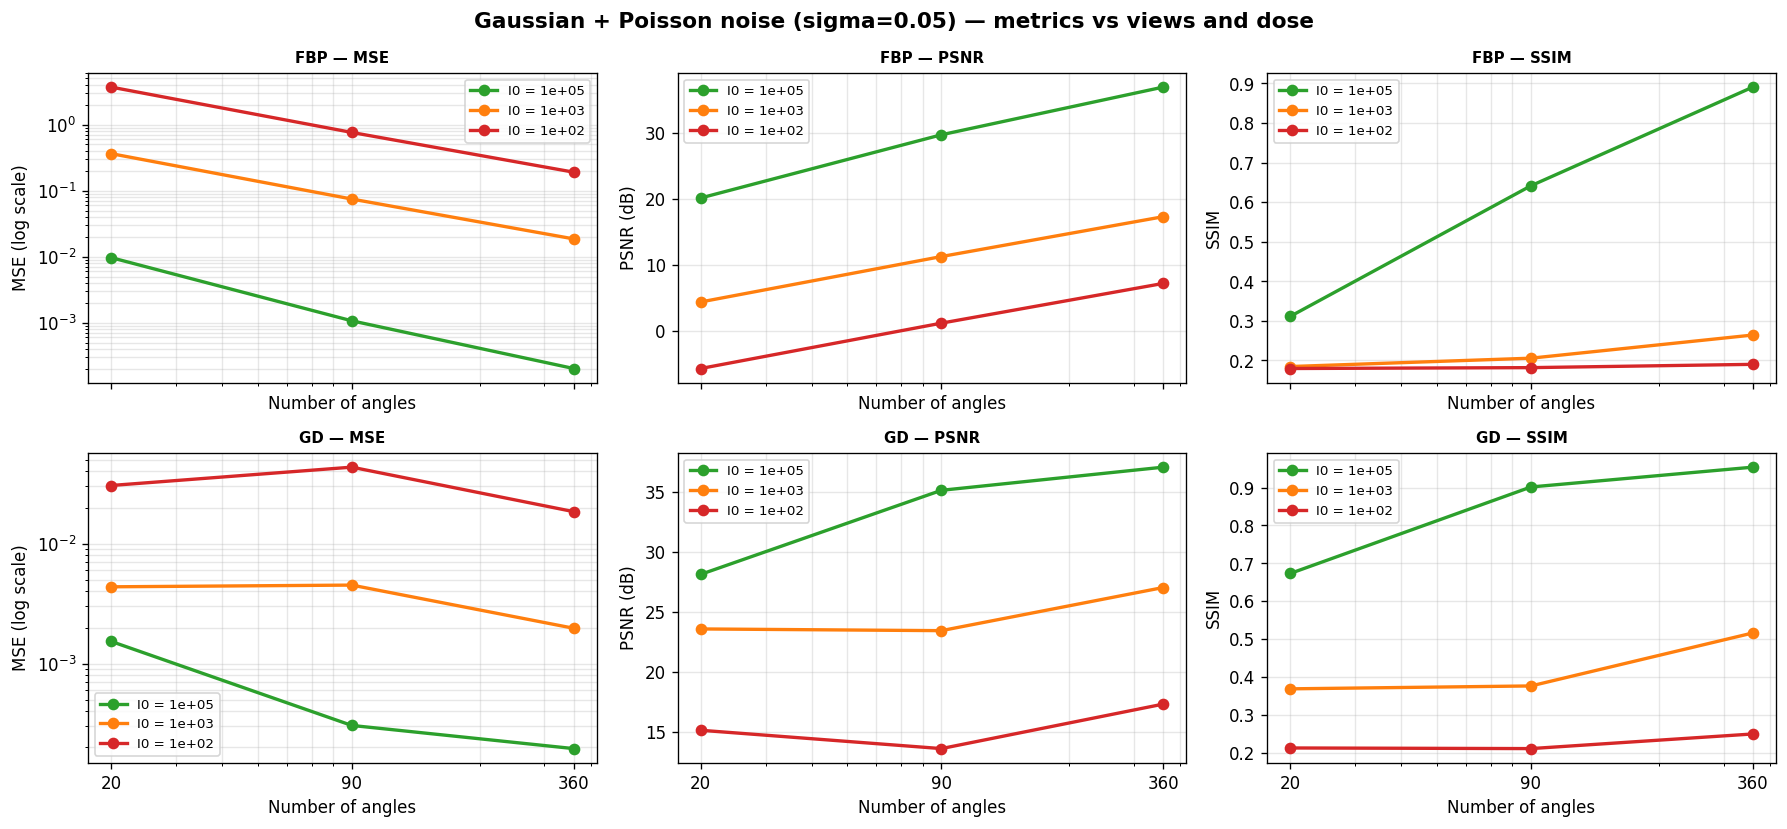

In [14]:
I0_colors = {1e5: "tab:green", 1e3: "tab:orange", 1e2: "tab:red"}
methods   = ["FBP", "GD"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)

for row, method in enumerate(methods):
    sub = metrics_df[metrics_df["method"] == method]

    for I0, color in I0_colors.items():
        s      = sub[sub["I0"] == I0].sort_values("angles")
        angles = s["angles"].values
        kw     = dict(color=color, marker="o", linewidth=2, markersize=6,
                      label=f"I0 = {I0:.0e}")

        axes[row, 0].semilogy(angles, s["MSE"],  **kw)
        axes[row, 1].plot(angles,     s["PSNR"], **kw)
        axes[row, 2].plot(angles,     s["SSIM"], **kw)

    for col, (ylabel, title) in enumerate([
        ("MSE (log scale)", f"{method} — MSE"),
        ("PSNR (dB)",       f"{method} — PSNR"),
        ("SSIM",            f"{method} — SSIM"),
    ]):
        ax = axes[row, col]
        ax.set_xscale("log")
        ax.set_xticks(angle_list); ax.set_xticklabels(angle_list)
        ax.set_xlabel("Number of angles")
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight="semibold")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(fontsize=8)

plt.suptitle(f"Gaussian + Poisson noise (sigma={sigma}) — metrics vs views and dose",
             fontsize=13, fontweight="semibold")
plt.tight_layout()
plt.show()

In [ ]:
# ── PSNR / SSIM heatmap — all 9 conditions, FBP and GD side by side ────────
methods   = ["FBP", "GD"]
psnr_grid = {m: np.zeros((3, 3)) for m in methods}
ssim_grid = {m: np.zeros((3, 3)) for m in methods}

for ri, I0 in enumerate(sorted(I0_list, reverse=True)):
    for ci, n in enumerate(sorted(angle_list, reverse=True)):
        psnr_grid["FBP"][ri, ci] = recon_results[n][I0]["fbp_metrics_noisy"]["PSNR"]
        psnr_grid["GD"][ri, ci]  = recon_results[n][I0]["gd_metrics_noisy"]["PSNR"]
        ssim_grid["FBP"][ri, ci] = recon_results[n][I0]["fbp_metrics_noisy"]["SSIM"]
        ssim_grid["GD"][ri, ci]  = recon_results[n][I0]["gd_metrics_noisy"]["SSIM"]

xlabels = [str(n) for n in sorted(angle_list, reverse=True)]
ylabels = ["$10^5$", "$10^3$", "$10^2$"]

fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True)

for col, method in enumerate(methods):
    # PSNR
    ax = axes[0, col]
    im = ax.imshow(psnr_grid[method], cmap="RdYlGn", vmin=-1, vmax=40, aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(xlabels)
    ax.set_yticks(range(3)); ax.set_yticklabels(ylabels)
    ax.set_xlabel("Number of views"); ax.set_ylabel("$I_0$ (photons)")
    ax.set_title(f"{method} — PSNR (dB)", fontweight="semibold")
    for ri in range(3):
        for ci in range(3):
            v = psnr_grid[method][ri, ci]
            ax.text(ci, ri, f"{v:.1f}", ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="white" if v < 15 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # SSIM
    ax = axes[1, col]
    im = ax.imshow(ssim_grid[method], cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(xlabels)
    ax.set_yticks(range(3)); ax.set_yticklabels(ylabels)
    ax.set_xlabel("Number of views"); ax.set_ylabel("$I_0$ (photons)")
    ax.set_title(f"{method} — SSIM", fontweight="semibold")
    for ri in range(3):
        for ci in range(3):
            v = ssim_grid[method][ri, ci]
            ax.text(ci, ri, f"{v:.3f}", ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="white" if v < 0.4 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("PSNR and SSIM across all 9 dose/view conditions",
             fontsize=12, fontweight="semibold")
fig.savefig(f"{SAVE_DIR}/metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

more angles = better reconstruction 
- more projections = more information 
- less ill-posed problem

high-dose -> best performance 

FBP VS GD
- GD has much lower MSE, higher PSNR and higer SSIM - it is much better than the FBF
- the biggest difference is at the low dose - as at the higher does the two methods are almost simmilar 
- GD is more robust to 
    - noise 
    - undersampling